In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import numpy as np

from load_meop import MEOP
from stericheight.plotting_fns import PlottingFns
from stericheight.data_handler import GEBCO

pfns = PlottingFns()

fname = '../data/CLIM_3D_forJenny.nc'

In [3]:
def crop_to_extent(ds, extent):
    return ds.where((ds.latitude >= extent[2]) & 
                    (ds.latitude <= extent[3]) &
                    (ds.longitude >= extent[0]) &
                    (ds.longitude <= extent[1]), drop=True)

In [4]:
elevation_ = GEBCO(coarsen_factor=40).ds.elevation


In [5]:
ds = xr.open_dataset(fname)
ds = ds.squeeze().rename({'lat':'latitude','lon':'longitude','prs':'pressure'}) \
    .swap_dims({'NB_y':'latitude','NB_x':'longitude','NB_LEV':'pressure'})

In [6]:
extent =[100,160,-69,-62]
extent_mertz =[138.5,143,-67,-62]

In [7]:
clim_mertz = crop_to_extent(ds,extent_mertz)
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))


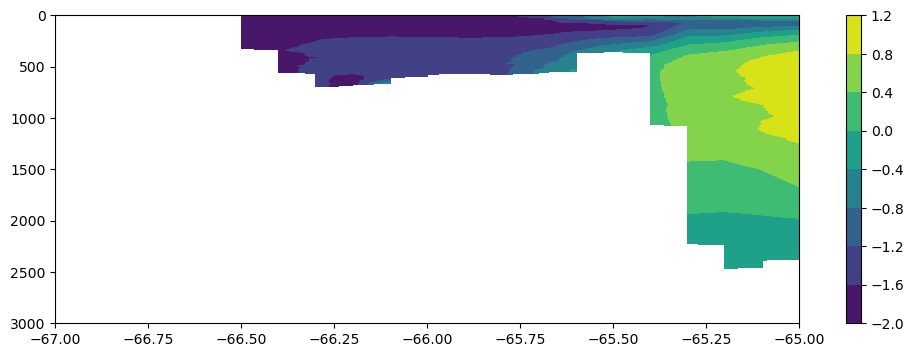

In [8]:
clim_139E = clim_mertz.where(clim_mertz.longitude==139,drop=True).squeeze()
fig, ax = plt.subplots(figsize=(12,4))
im=ax.contourf(clim_139E.latitude,clim_139E.pressure,clim_139E.ct)
ax.set_ylim([0,3000])
ax.invert_yaxis()
plt.colorbar(im)


In [9]:
meop_mertz=MEOP(extent=extent_mertz)
df1=meop_mertz.load_profiles()

100%|██████████| 82/82 [01:06<00:00,  1.23it/s]


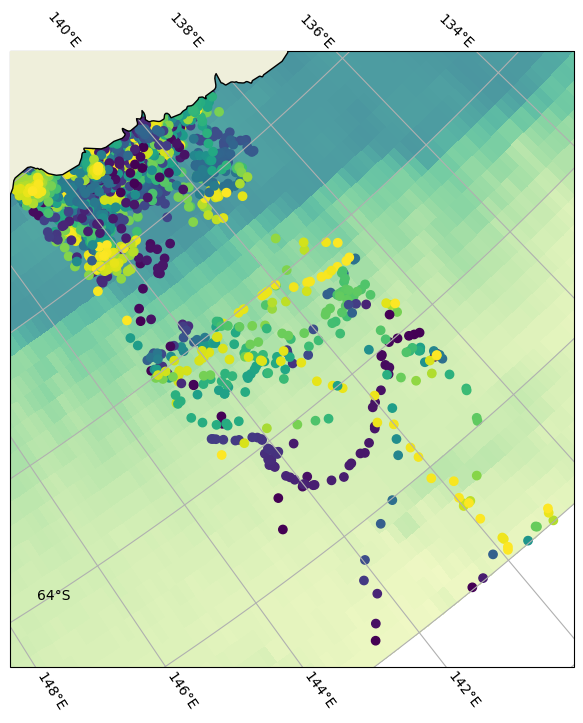

In [ ]:
fig,ax=plt.subplots(figsize=(10,8),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent_mertz,cmap=cmocean.cm.deep,land_zorder=3)
for platform in df1.platform.unique():
    dff = df1[df1.platform == platform]
    im=ax.scatter(dff.longitude,dff.latitude,c=dff.index,transform=ccrs.PlateCarree(),label=platform)
#ax.legend()

In [11]:
onshelf = meop_mertz.df[meop_mertz.df.latitude < -65.4]
ofshelf = meop_mertz.df[meop_mertz.df.latitude > -65.4]


In [12]:
ontemp,onpsal,ondf = meop_mertz.reindex_profiles(onshelf)

reindexing temps..
reindexing psals...
merging...


In [13]:
oftemp,ofpsal,ofdf = meop_mertz.reindex_profiles(ofshelf)

reindexing temps..
reindexing psals...
merging...


In [14]:
ontemp_monthly = ontemp.groupby('time.month').mean()
onpsal_monthly = onpsal.groupby('time.month').mean()
oftemp_monthly = oftemp.groupby('time.month').mean()
ofpsal_monthly = ofpsal.groupby('time.month').mean()

In [15]:
ontemp_monthly

<xarray.DataArray 'TEMP_ADJUSTED' (month: 12, pressure: 54)> Size: 3kB
array([[-1.6057805, -1.6235628, -1.602473 , -1.5564415, -1.559888 ,
        -1.5616802, -1.5625966, -1.5652364, -1.5673621, -1.5694932,
        -1.5720953, -1.5730034, -1.5747625, -1.5769613, -1.5812058,
        -1.5848138, -1.5874345, -1.5900044, -1.592266 , -1.5942712,
        -1.595972 , -1.59644  , -1.5966817, -1.5974323, -1.5977036,
        -1.6000346, -1.597392 , -1.5986727, -1.5994589, -1.6017648,
        -1.6045128, -1.6051693, -1.605508 , -1.6086756, -1.6120317,
        -1.6129422, -1.6171169, -1.6200475, -1.6206192, -1.6200671,
        -1.6146977, -1.6099085, -1.6099408, -1.6183724, -1.6133757,
        -1.6443175, -1.6371963, -1.6282483, -1.6276993, -1.6306992,
        -1.6400754, -1.6576709, -1.6834642, -1.7523537],
       [-1.5690424, -1.5376267, -1.5332968, -1.5317414, -1.5280812,
        -1.5257508, -1.5244267, -1.5205951, -1.5168003, -1.5119101,
        -1.5089397, -1.508673 , -1.5069311, -1.5042831, -1.5018177,
        -1.5000874, -1.4990703, -1.4970403, -1.4936433, -1.4915891,
        -1.4901887, -1.4896767, -1.4889865, -1.4890237, -1.4871038,
        -1.483598 , -1.4849575, -1.4853603, -1.4836572, -1.4826771,
        -1.480685 , -1.4813609, -1.4813344, -1.4805425, -1.4771622,
        -1.4769082, -1.4743291, -1.4715731, -1.471661 , -1.4738295,
        -1.4753492, -1.4718827, -1.4812868, -1.4917028, -1.4958514,
...
        -1.8688879, -1.8690482, -1.8691916, -1.8689977, -1.8693651,
        -1.8697721, -1.8708547, -1.8710972, -1.8716357, -1.8720622,
        -1.8720019, -1.8721583, -1.8722435, -1.8728312, -1.8736007,
        -1.8741583, -1.874493 , -1.8746142, -1.8749586, -1.8753654,
        -1.8763884, -1.8763567, -1.876401 , -1.8766208, -1.8775833,
        -1.8777634, -1.8789998, -1.880028 , -1.8803096, -1.8811595,
        -1.8806279, -1.8810296, -1.8816614, -1.8824188, -1.8833014,
        -1.8841946, -1.8846262, -1.886208 , -1.8885046, -1.8892481,
        -1.8886594, -1.8878654, -1.8930601, -1.9024636],
       [-1.6701103, -1.6966562, -1.6979707, -1.706117 , -1.7080655,
        -1.7093335, -1.7100278, -1.7119308, -1.7140942, -1.7163873,
        -1.7184937, -1.7191784, -1.7205336, -1.7224295, -1.724307 ,
        -1.7267584, -1.7292104, -1.731231 , -1.733146 , -1.7349864,
        -1.7365925, -1.7377132, -1.7383963, -1.74037  , -1.7426302,
        -1.7474818, -1.7478553, -1.7525641, -1.7564117, -1.7595502,
        -1.7624869, -1.763494 , -1.7639832, -1.7671688, -1.7693157,
        -1.7699643, -1.7736062, -1.7761825, -1.7767471, -1.778236 ,
        -1.7807746, -1.7852359, -1.7878633, -1.791023 , -1.7938468,
        -1.7958764, -1.7973573, -1.7972678, -1.7982057, -1.8006704,
        -1.7993617, -1.7969491, -1.7813631, -1.7547958]], dtype=float32)
Coordinates:
  * pressure  (pressure) float32 216B 4.0 6.0 8.0 10.0 ... 200.0 300.0 400.0
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    long_name:  SEA TEMPERATURE IN SITU ITS-90 SCALE
    units:      degree_Celsius
    valid_min:  -2.0
    valid_max:  40.0
    comment:    In situ measurement

Text(0.5, 1.0, 'Off-shelf salinity')

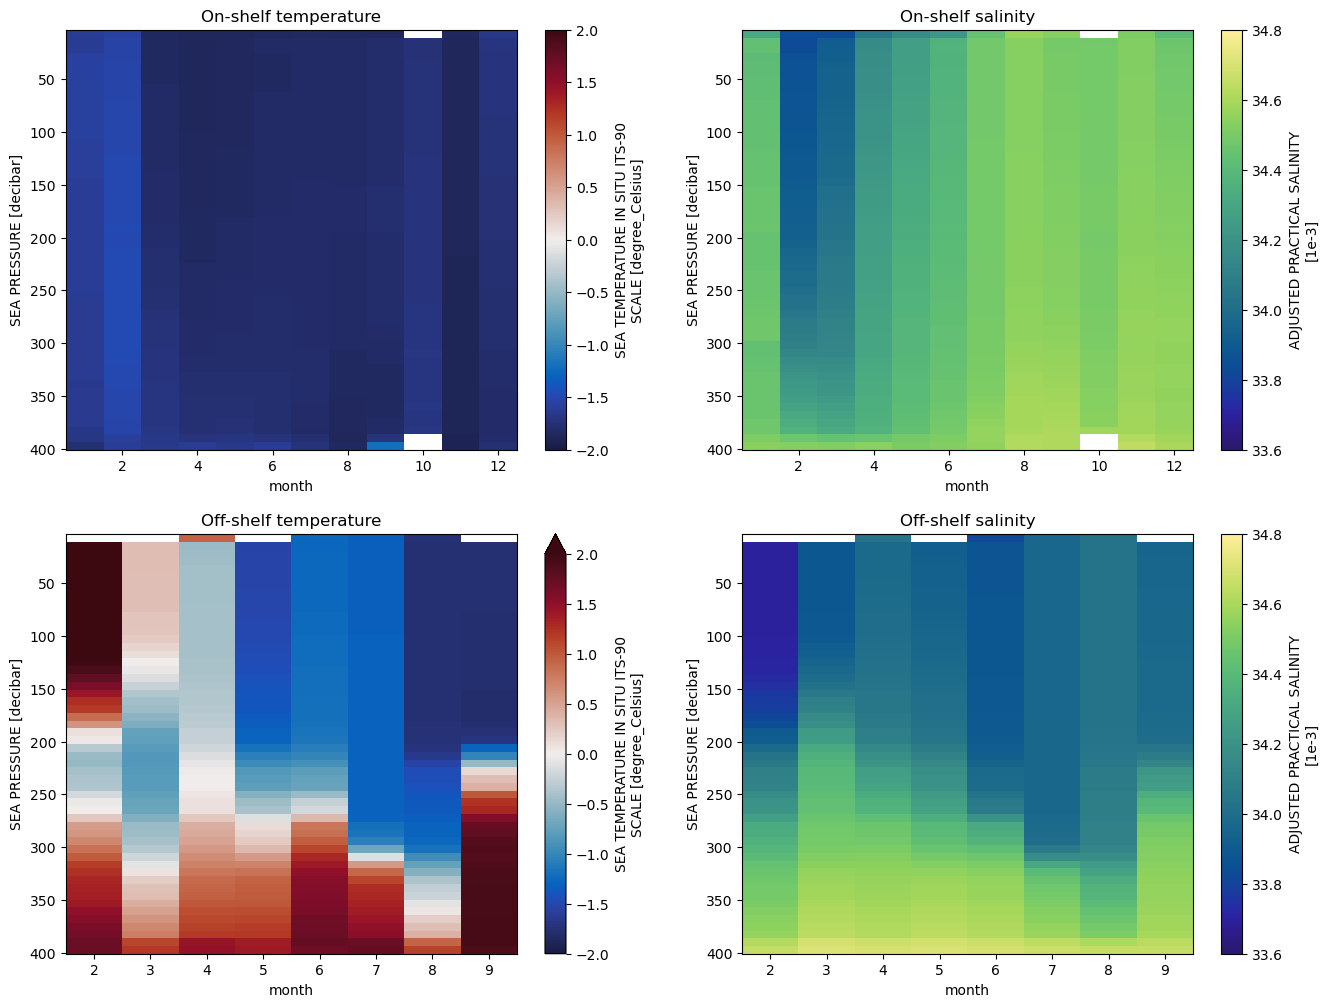

In [24]:
fig,axs = plt.subplots(2,2,figsize=(16,12))
ax=axs[0][0]
ontemp_monthly.plot.imshow(x='month',y='pressure',ax=ax,vmin=-2,vmax=2,cmap=cmocean.cm.balance)
ax.invert_yaxis()
ax.set_title('On-shelf temperature')

ax=axs[0][1]
onpsal_monthly.plot.imshow(x='month',y='pressure',ax=ax,vmin=33.6,vmax=34.8,cmap=cmocean.cm.haline)
ax.invert_yaxis()
ax.set_title('On-shelf salinity')

ax=axs[1][0]
oftemp_monthly.plot.imshow(x='month',y='pressure',ax=ax,vmin=-2,vmax=2,cmap=cmocean.cm.balance)
ax.invert_yaxis()
ax.set_title('Off-shelf temperature')

ax=axs[1][1]
ofpsal_monthly.plot.imshow(x='month',y='pressure',ax=ax,vmin=33.6,vmax=34.8,cmap=cmocean.cm.haline)
ax.invert_yaxis()
ax.set_title('Off-shelf salinity')